In [28]:
import pandas as pd
import os
import yaml

import matplotlib.pyplot as plt

from macro_explorer.util.census_helpers import CensusApi
from macro_explorer.steps.get_remi_hh_units import load_remi_pop

cfg = yaml.safe_load(open('configs/settings.yaml'))

In [31]:
def clean_growth_targets(cfg):
    df_out = pd.DataFrame()
    for target in cfg['growth_targets']:
        target_baseyear = target['base_year']
        target_year = target['target_year']
        base_type = target['base_type']
        df = pd.read_csv(os.path.join(cfg['data_dir'], target['filename']))
        df = df.groupby('county_id')[[f'{base_type}_units',f'units_{target_year}',f'{base_type}_total_pop',f'total_pop_{target_year}']].sum().round(0).astype(int)
        df = df.rename(columns={f'{base_type}_units': f'units_{target_baseyear}', f'{base_type}_total_pop': f'total_pop_{target_baseyear}'})
        df = pd.wide_to_long(df.reset_index(), stubnames=['units', 'total_pop'], i='county_id', j='year', sep='_').sort_index().reset_index()
        df['units'] = df['units'].replace(0, float('nan'))
        df['name'] = target['name']
        df_out = pd.concat([df_out, df], ignore_index=True)
    return df_out

growth_targets = clean_growth_targets(cfg)
growth_targets['type'] = 'Growth Target'

In [32]:
remi_hist = (
    load_remi_pop(f"{cfg['data_dir']}/{cfg['remi_history_file']}", cfg['county_map'])
    .groupby(['year', 'county_id'], as_index=False)[['total_pop']].sum().astype('int')
    .assign(
        name='REMI History',
        type='Historical'
    )
)

c:\Users\JKolberg\PythonProjects\macro-explorer\.venv\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [33]:
def clean_ofm(cfg,file_path,ofm_type):
    ofm_types = {'total_pop': 'Population', 'units': 'Housing Units'}
    skip_rows = {'total_pop': 4, 'units': 3}
    col_filter = {'total_pop': None, 'units': 'Total Housing Units'}
    df = pd.read_excel(file_path,skiprows=skip_rows[ofm_type],sheet_name=ofm_types[ofm_type])
    df['county_id'] = df['Jurisdiction'].map(cfg['county_map'])
    df = df.loc[df['county_id'].notna()].copy()
    flt = col_filter[ofm_type]
    value_cols = [c for c in df.columns if c[:4].isdigit() and (flt is None or flt in c)]
    df = df.rename(columns={c: c[:4] for c in value_cols})
    year_cols = [str(y) for y in range(2020, 2026)]
    ofm = df[['county_id'] + year_cols].melt(id_vars='county_id', var_name='year', value_name=ofm_type)
    return ofm

ofm_pop_path = os.path.join(cfg['data_dir'], cfg['ofm_population_file'])
ofm_pop = clean_ofm(cfg,ofm_pop_path,'total_pop')
ofm_housing_path = os.path.join(cfg['data_dir'], cfg['ofm_housing_file'])
ofm_housing = clean_ofm(cfg,ofm_housing_path,'units')
ofm = ofm_pop.merge(ofm_housing, on=['county_id', 'year'])
ofm['year'] = ofm['year'].astype(int)
ofm['name'] = 'OFM'
ofm['type'] = 'Historical'

In [34]:
def clean_pep(cfg,file_path,pep_type):
    df = pd.read_excel(file_path,skiprows=2,header=[0,1])
    year_cols = [str(y) for y in range(2020, 2026)]
    df.columns = ['geog', 'april2020'] + year_cols
    df['county_id'] = df['geog'].str.lstrip('.').str.split(',').str[0].map(cfg['county_map'])
    df = df.loc[df['county_id'].notna()].copy().set_index('county_id')
    return df[year_cols].reset_index().melt(id_vars='county_id', var_name='year', value_name=pep_type)
    

In [35]:
pep_pop_path = os.path.join(cfg['data_dir'], cfg['pep_population_file'])
pep_pop = clean_pep(cfg,pep_pop_path,'total_pop')
pep_housing_path = os.path.join(cfg['data_dir'], cfg['pep_housing_file'])
pep_housing = clean_pep(cfg,pep_housing_path,'units')
pep = pep_pop.merge(pep_housing, on=['county_id','year'])
pep['year'] = pep['year'].astype(int)
pep['name'] = 'PEP'
pep['type'] = 'Historical'

In [36]:
acs = pd.read_csv(os.path.join(cfg['data_dir'], 'acs_county_totals.csv'))
acs['name'] = 'ACS'
acs_occ = acs.sort_values('year',ascending=False).drop_duplicates('county_id').set_index('county_id')['occupancy']
acs['type'] = 'Historical'

In [37]:
dec = pd.read_csv(f"{cfg['data_dir']}/decennial_totals.csv")
dec_occ = dec.sort_values('year',ascending=False).drop_duplicates('county_id').set_index('county_id')['occupancy']
dec['name'] = 'Decennial'
dec['type'] = 'Historical'

In [38]:
remi = (
    pd.read_csv(f"{cfg['data_dir']}/{cfg['remi_output_file']}")
    .query('year > @cfg["remi_base_year"]')
)
remi['occupancy'] = remi['county_id'].map(acs_occ)
remi['units'] = (remi['hh'] / remi['occupancy']).round(0).astype(int)
remi['hhsz'] = remi['hhpop'] / remi['hh']
remi['type'] = 'Forecast'

In [39]:
def clean_luvit(df,dec_occ):
    value_cols = [c for c in df.columns if c[:4].isdigit()]
    df['county_id'] = df['Region'].map(cfg['county_map'])
    col_dict = {
        'Total Population': 'total_pop',
        'Household Population': 'hhpop',
        'Households': 'hh',
    }
    out_df = pd.DataFrame()
    for col in col_dict.keys():
        temp_df = (
            df.loc[(df.county_id.notna()) & (df['Detailed Measure'] == col)]
            .set_index('county_id')[value_cols]
            .reset_index()
            .melt(id_vars='county_id', var_name='year', value_name=col_dict[col])
            .assign(**{col_dict[col]: lambda x: (x[f'{col_dict[col]}'] * 1000).round(0).astype(int)})
        )
        out_df = out_df.merge(temp_df, on=['county_id', 'year'], how='outer') if not out_df.empty else temp_df
    out_df['units'] = out_df['hh'] / out_df['county_id'].map(dec_occ)
    out_df['gq'] = out_df['total_pop'] - out_df['hhpop']
    out_df['hhsz'] = out_df['hhpop'] / out_df['hh']
    out_df['name'] = 'LUVIT'
    out_df['type'] = 'Forecast'
    out_df['year'] = out_df['year'].astype(int)
    return out_df

luvit= pd.read_csv(f"{cfg['data_dir']}/{cfg['luvit_forecast_file']}")
luvit = clean_luvit(luvit, dec_occ)

In [40]:
def clean_woods_poole(cfg, acs_occ):
    wp_files = {county_id: filename for d in cfg['woods_poole_files'] for county_id, filename in d.items()}
    row_map = {
        'TOTAL POPULATION (in thousands)': 'total_pop',
        'TOTAL NUMBER of HOUSEHOLDS (in thousands)': 'hh',
    }
    df_out = pd.DataFrame()
    for county_id, filename in wp_files.items():
        file_path = os.path.join(cfg['woods_poole_forecast_dir'], filename)
        raw = pd.read_csv(file_path, skiprows=2, index_col=0)
        wp = raw.loc[list(row_map.keys())].rename(index=row_map).T.reset_index().rename(columns={'index': 'year'})
        wp['year'] = wp['year'].astype(int)
        value_cols = list(row_map.values())
        wp[value_cols] = (wp[value_cols].astype(float) * 1000).round(0).astype(int)
        wp['county_id'] = county_id
        df_out = pd.concat([df_out, wp], ignore_index=True)
    df_out['occupancy'] = df_out['county_id'].map(acs_occ)
    df_out['units'] = (df_out['hh'] / df_out['occupancy']).round(0).astype(int)
    df_out['name'] = 'Woods & Poole'
    df_out['type'] = 'Forecast'
    return df_out

wp = clean_woods_poole(cfg, acs_occ)

In [41]:
df = pd.concat([dec,acs, remi,pep,ofm,remi_hist,growth_targets,luvit,wp], ignore_index=True)

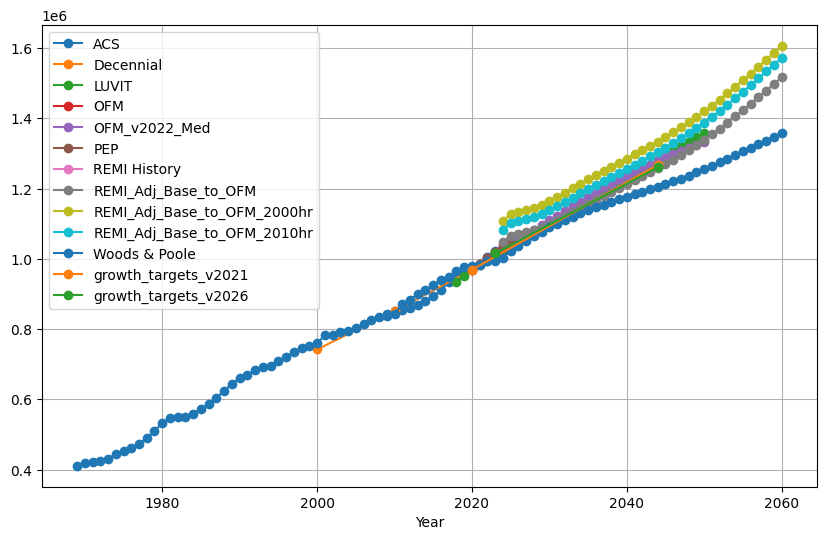

In [42]:
# create a line plot of hhpop over time
plt.figure(figsize=(10, 6))
for name, group in df.loc[df.county_id==53033].groupby('name'):
    plt.plot(group['year'], group['units'], marker='o', label=f'{name}')
plt.xlabel('Year')
plt.legend()
plt.grid()
plt.show()


In [ ]:
df['name'].unique()

In [ ]:
df.columns

In [ ]:
with pd.ExcelWriter(os.path.join(cfg['output_dir'], 'forecasts_and_history.xlsx')) as writer:
    for name in ['REMI History', 'OFM', 'Decennial', 'REMI_Adj_Base_to_OFM','OFM_v2022_Med','growth_targets_v2026', 'LUVIT']:
        print(name)
        temp_df = df[df['name']==name].groupby('year')[['total_pop','hhpop','gq','hh','units']].sum().round(0).astype(int).reset_index()
        temp_df['hhsz'] = (temp_df['hhpop'] / temp_df['hh']).round(2)
        temp_df['occupancy'] = (temp_df['hh'] / temp_df['units']).round(2)
        temp_df.to_excel(writer, sheet_name=name)

In [ ]:
df.pivot(index=['county_id', 'name'], columns='year', values='units')